### **Definición general de una fila**

> Cada fila del fichero representa **una opinión personal de un paciente** sobre el uso de un medicamento para una condición médica específica, con su valoración y metadatos asociados (fecha y número de votos de utilidad).

---

### **Estructura y descripción de las columnas**

| Columna         | Tipo               | Descripción                                                                                                                            |
| --------------- | ------------------ | -------------------------------------------------------------------------------------------------------------------------------------- |
| **drugName**    | `str`              | Nombre del medicamento reseñado (por ejemplo: `"Metformin"`, `"Ibuprofen"`).                                                           |
| **condition**   | `str`              | Condición médica o enfermedad tratada (por ejemplo: `"Diabetes Type 2"`, `"Pain"`). Puede tener valores nulos o inconsistentes.        |
| **review**      | `str`              | Texto libre escrito por el paciente describiendo su experiencia con el fármaco (efectividad, efectos secundarios, duración, etc.).     |
| **rating**      | `float`            | Puntuación otorgada por el usuario (escala de 1 a 10). Suele interpretarse como medida de **satisfacción general** con el medicamento. |
| **date**        | `str` / `datetime` | Fecha en que se publicó la reseña.                                                                                                     |
| **usefulCount** | `int`              | Número de usuarios que marcaron la reseña como “útil”. Es un indicador de relevancia o fiabilidad percibida por otros.                 |

---

### **Ejemplo de fila**

| drugName    | condition         | review                                                                | rating | date       | usefulCount |
| ----------- | ----------------- | --------------------------------------------------------------------- | ------ | ---------- | ----------- |
| *Metformin* | *Diabetes Type 2* | “It helped lower my sugar levels, but I had stomach pain for a week.” | 8      | 2012-05-04 | 215         |

Esta fila indica que un usuario tomó **Metformin** para **Diabetes Tipo 2**, dejó una **reseña textual** (sentimiento mixto), le dio **8/10** y su reseña fue considerada útil **215 veces**.

---

### **Propósito de los dos ficheros**

* **`drugsComTrain_raw.csv`** → conjunto de **entrenamiento** (aprox. 160 000 reseñas).
* **`drugsComTest_raw.csv`** → conjunto de **evaluación/test** (aprox. 54 000 reseñas).
  Ambos tienen la misma estructura y provienen del mismo origen; la división ya viene establecida para experimentos reproducibles (p. ej., clasificación de sentimiento, resumen, etc.).

---

In [1]:
# ================================
# 1. Montar Google Drive
# ================================
from google.colab import drive
drive.mount('/content/drive')

# Ruta donde están tus archivos CSV (ajústala según tu carpeta)
path = "/content/drive/MyDrive/Colab Notebooks/Python-Ejercicios/07 - PLN/ACTIVIDADES CURSO/"


Mounted at /content/drive


In [31]:

# ================================
# 2. Leer ficheros
# ================================
import pandas as pd

train_path = path + "drugsComTrain_raw.csv"
test_path  = path + "drugsComTest_raw.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)



In [32]:
# ================================
# 3. Información general
# ================================
print("=== TRAIN ===")
print(df_train.shape)
print(df_train.columns)
print(df_train.head(3))



=== TRAIN ===
(161297, 7)
Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount'],
      dtype='object')
   uniqueID    drugName                     condition  \
0    206461   Valsartan  Left Ventricular Dysfunction   
1     95260  Guanfacine                          ADHD   
2     92703      Lybrel                 Birth Control   

                                              review  rating       date  \
0  "It has no side effect, I take it in combinati...       9  20-May-12   
1  "My son is halfway through his fourth week of ...       8  27-Apr-10   
2  "I used to take another oral contraceptive, wh...       5  14-Dec-09   

   usefulCount  
0           27  
1          192  
2           17  


In [33]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   uniqueID     161297 non-null  int64 
 1   drugName     161297 non-null  object
 2   condition    160398 non-null  object
 3   review       161297 non-null  object
 4   rating       161297 non-null  int64 
 5   date         161297 non-null  object
 6   usefulCount  161297 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 8.6+ MB


In [34]:
df_train.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [35]:
print("\n=== TEST ===")
print(df_test.shape)
print(df_test.columns)
print(df_test.head(3))


=== TEST ===
(53766, 7)
Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount'],
      dtype='object')
   uniqueID     drugName                     condition  \
0    163740  Mirtazapine                    Depression   
1    206473   Mesalamine  Crohn's Disease, Maintenance   
2    159672      Bactrim       Urinary Tract Infection   

                                              review  rating       date  \
0  "I&#039;ve tried a few antidepressants over th...      10  28-Feb-12   
1  "My son has Crohn&#039;s disease and has done ...       8  17-May-09   
2                      "Quick reduction of symptoms"       9  29-Sep-17   

   usefulCount  
0           22  
1           17  
2            3  


In [36]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53766 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   uniqueID     53766 non-null  int64 
 1   drugName     53766 non-null  object
 2   condition    53471 non-null  object
 3   review       53766 non-null  object
 4   rating       53766 non-null  int64 
 5   date         53766 non-null  object
 6   usefulCount  53766 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 2.9+ MB


In [37]:
df_test.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4


In [38]:
# ================================
# 4. Tipos y nulos
# ================================
print("\n--- Tipos de datos ---")
print(df_train.dtypes)

print("\n--- Nulos TRAIN ---")
print(df_train.isnull().sum())

print("\n--- Nulos TEST ---")
print(df_test.isnull().sum())


--- Tipos de datos ---
uniqueID        int64
drugName       object
condition      object
review         object
rating          int64
date           object
usefulCount     int64
dtype: object

--- Nulos TRAIN ---
uniqueID         0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

--- Nulos TEST ---
uniqueID         0
drugName         0
condition      295
review           0
rating           0
date             0
usefulCount      0
dtype: int64


## **¿Qué vamos a hacer?**
---

## Proyecto: Análisis y generación de respuestas automáticas sobre reseñas de fármacos

**Dataset:** *Drug Review Dataset (UCI/Kaggle)*
**Archivos:** `drugsComTrain_raw.csv` y `drugsComTest_raw.csv`
**Unidad temática:** PLN – IA Salud
**Lengua original:** Inglés

---

## 1. Análisis Exploratorio de Datos (EDA)

**Objetivo:** comprender la estructura, distribución y características textuales del dataset antes de aplicar modelos de NLP o de aprendizaje automático.

###  Acciones posibles

1. **Exploración general de metadatos**

   * Número de reseñas por medicamento y por condición.
   * Distribución de ratings (de 1 a 10).
   * Distribución temporal (reseñas por año o mes).
   * Conteo y proporción de reseñas con `usefulCount` elevado (relevancia).

2. **Análisis textual básico**

   * Longitud media de las reseñas (palabras, caracteres).
   * Frecuencias de palabras más comunes y términos médicos recurrentes.
   * Nube de palabras por sentimiento (positivas vs negativas).
   * Tokenización, lematización y eliminación de stopwords.

3. **Correlaciones cuantitativas**

   * Relación entre `rating` y `usefulCount` → ¿las reseñas positivas son más votadas?
   * Correlación entre longitud del texto y valoración.
   * Distribución de sentimiento según condición médica.

4. **Visualización**

   * Histogramas de ratings.
   * Diagramas de dispersión (`rating` vs `usefulCount`).
   * Boxplots por medicamento.
   * Series temporales de frecuencia de reseñas.

---

## 2. Análisis de Sentimiento y Comparación con el Rating

**Objetivo:** evaluar si el lenguaje de las reseñas coincide con las valoraciones numéricas, y construir un modelo de **clasificación automática**.

### Enfoques posibles

1. **Pipeline preentrenado (sin entrenamiento adicional)**
   Usar modelos de Transformers como `distilbert-base-uncased-finetuned-sst-2-english` para clasificar reseñas en *positive / negative / neutral*.

2. **Entrenamiento supervisado**

   * Etiquetar automáticamente según `rating`:

     * `rating >= 7` → positivo
     * `rating <= 4` → negativo
     * valores intermedios → neutro
   * Entrenar un modelo (Logistic Regression, SVM, o Transformer fine-tuning) y evaluar precisión, recall, F1.

3. **Comparativa y validación**

   * Comparar sentimiento del modelo con el `rating` numérico.
   * Analizar discrepancias (casos con sentimiento negativo pero rating alto, y viceversa).
   * Evaluar si reseñas con más “usefulCount” son más congruentes (posible indicador de fiabilidad).

4. **Análisis interpretativo (XAI)**

   * Aplicar técnicas como **SHAP** o **LIME** para explicar qué palabras contribuyen al sentimiento.
   * Detectar patrones lingüísticos asociados a efectos secundarios o satisfacción.

---

## 3. Chat Automatizado de Recomendación Educativa

**Objetivo:** crear un **bot educativo** que responda automáticamente a los usuarios con mensajes empáticos y recomendaciones informativas, **sin sustituir la atención médica**.

### Flujo del bot

1. **Entrada:** texto libre del usuario (reseña, duda o comentario).

2. **Procesamiento:**

   * Limpieza y detección de idioma.
   * Análisis de **sentimiento** (positivo / negativo / neutro).
   * **Resumen automático** (síntesis de la experiencia).
   * **Reconocimiento de entidades médicas (NER)** → fármaco, condición, efectos.

3. **Salida:**

   * Mensaje de respuesta empática (“Lamento que hayas tenido molestias con Metformin…”).
   * Resumen del sentimiento (“tu experiencia parece moderadamente positiva”).
   * **Recomendaciones educativas** (extraídas de MedQuAD, MESINESP o de un corpus simulado) con información sobre uso seguro o efectos comunes.
   * **Aviso de seguridad:** “Esta información no sustituye la orientación médica profesional.”

4. **Aprendizaje incremental (opcional):**

   * Guardar interacciones anónimas para mejorar respuestas o ajustar el modelo de recomendación.
   * Priorización de respuestas más útiles (según feedback del usuario).

---

## 4. Aplicaciones educativas en el marco PLN – IA Salud

* Mostrar a los estudiantes cómo **conectar análisis estadístico, PLN y ética médica**.
* Comprender cómo los modelos de lenguaje procesan **opiniones reales de pacientes**.
* Experimentar con **técnicas de interpretabilidad (XAI)** sobre texto médico.
* Desarrollar un **bot responsable** que prioriza educación y transparencia.

---



## 1. Análisis Exploratorio de Datos (EDA)

**Objetivo:** comprender la estructura, distribución y características textuales del dataset antes de aplicar modelos de NLP o de aprendizaje automático.

###  Acciones posibles

1. **Exploración general de metadatos**

   * Número de reseñas por medicamento y por condición.
   * Distribución de ratings (de 1 a 10).
   * Distribución temporal (reseñas por año o mes).
   * Conteo y proporción de reseñas con `usefulCount` elevado (relevancia).

2. **Análisis textual básico**

   * Longitud media de las reseñas (palabras, caracteres).
   * Frecuencias de palabras más comunes y términos médicos recurrentes.
   * Nube de palabras por sentimiento (positivas vs negativas).
   * Tokenización, lematización y eliminación de stopwords.

3. **Correlaciones cuantitativas**

   * Relación entre `rating` y `usefulCount` → ¿las reseñas positivas son más votadas?
   * Correlación entre longitud del texto y valoración.
   * Distribución de sentimiento según condición médica.

4. **Visualización**

   * Histogramas de ratings.
   * Diagramas de dispersión (`rating` vs `usefulCount`).
   * Boxplots por medicamento.
   * Series temporales de frecuencia de reseñas.


###**Procedamos primero con la limpieza de datos**

In [39]:
# Copiamos solo columnas esenciales
import re # Importamos el módulo re

cols = ["drugName", "condition", "review", "rating", "date", "usefulCount"]
df_train = df_train[cols].copy()
df_test  = df_test[cols].copy()

# ================================
# Función de limpieza de texto
# ================================
def clean_review(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()                           # minúsculas
    text = re.sub(r"<br\\s*/?>", " ", text)            # etiquetas HTML
    text = re.sub(r"[^a-zA-Z0-9.,!?\\s']", " ", text)  # elimina símbolos no alfanuméricos
    text = re.sub(r"http\\S+|www\\.\\S+", " ", text)   # elimina URLs
    text = re.sub(r"\\s+", " ", text).strip()          # espacios múltiples
    text = re.sub(r"([!?.,])\\1+", r"\\1", text)       # repeticiones
    return text

# Aplicamos limpieza
df_train["review_clean"] = df_train["review"].apply(clean_review)
df_test["review_clean"]  = df_test["review"].apply(clean_review)

# ================================
# Verificación rápida
# ================================
print("Ejemplo de texto antes y después de la limpieza:")
for i in range(3):
    print("\n--- Original ---\n", df_train.loc[i, "review"])
    print("--- Limpio ---\n", df_train.loc[i, "review_clean"])

Ejemplo de texto antes y después de la limpieza:

--- Original ---
 "It has no side effect, I take it in combination of Bystolic 5 Mg and Fish Oil"
--- Limpio ---
 it has no side effect, i take it in combination of bystolic 5 mg and fish oil

--- Original ---
 "My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get out of bed, was very cranky, and slept for nearly 8 hours on a drive home from school vacation (very unusual for him.) I called his doctor on Monday morning and she said to stick it out a few days. See how he did at school, and with getting up in the morning. The last two days have been problem free. He is MUCH more agreeable than ever. He is less emotional (a good thing), less cranky. He is remembering all the things he should. Overall his behavior is better. 
We have tried many different medications and so far this is the most effective.

In [40]:
# Eliminamos reseñas vacías o extremadamente cortas (<10 caracteres)
df_train = df_train[df_train["review_clean"].str.len() > 10].copy()
df_test  = df_test[df_test["review_clean"].str.len() > 10].copy()

# Eliminamos ratings nulos o fuera de rango
df_train = df_train[df_train["rating"].between(1, 10)]
df_test  = df_test[df_test["rating"].between(1, 10)]

# Reiniciamos índices
df_train.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

print(f"Train limpio: {df_train.shape}")
print(f"Test limpio: {df_test.shape}")


Train limpio: (160945, 7)
Test limpio: (53634, 7)


**Algunas comprobaciones tras la limpieza de datos**

In [41]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160945 entries, 0 to 160944
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   drugName      160945 non-null  object
 1   condition     160046 non-null  object
 2   review        160945 non-null  object
 3   rating        160945 non-null  int64 
 4   date          160945 non-null  object
 5   usefulCount   160945 non-null  int64 
 6   review_clean  160945 non-null  object
dtypes: int64(2), object(5)
memory usage: 8.6+ MB


In [42]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53634 entries, 0 to 53633
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   drugName      53634 non-null  object
 1   condition     53339 non-null  object
 2   review        53634 non-null  object
 3   rating        53634 non-null  int64 
 4   date          53634 non-null  object
 5   usefulCount   53634 non-null  int64 
 6   review_clean  53634 non-null  object
dtypes: int64(2), object(5)
memory usage: 2.9+ MB


In [43]:
# Longitud media de reseñas
df_train["review_len"] = df_train["review_clean"].str.split().apply(len)
print("\nLongitud promedio:", df_train["review_len"].mean())

# Distribución rápida de ratings
print("\nDistribución de ratings:")
print(df_train["rating"].value_counts().sort_index())



Longitud promedio: 88.71600236105502

Distribución de ratings:
rating
1     21600
2      6929
3      6511
4      5008
5      8010
6      6333
7      9445
8     18853
9     27470
10    50786
Name: count, dtype: int64


**Qué logramos con esta fase:**

- Reseñas homogéneas, sin HTML ni ruido.
- Campos listos para análisis de frecuencia, sentimiento o resumen.
- Eliminación de registros vacíos o inconsistentes.

Continuamos con el análisis exploratorio de datos.

In [44]:
# columnas auxiliares
df_train["review_len"] = df_train["review_clean"].str.split().apply(len)
df_test["review_len"]  = df_test["review_clean"].str.split().apply(len)

# parse de fecha
for df in (df_train, df_test):
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

/tmp/ipython-input-1416599948.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")
/tmp/ipython-input-1416599948.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


In [45]:
df_test.head()

,drugName,condition,review,rating,date,usefulCount,review_clean,review_len
0,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,2012-02-28,22,i 039 ve tried a few antidepressants over the...,72
1,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,2009-05-17,17,my son has crohn 039 s disease and has done v...,52
2,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,2017-09-29,3,quick reduction of symptoms,4
3,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,2017-03-05,35,contrave combines drugs that were used for alc...,158
4,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,2015-10-22,4,i have been on this birth control for one cycl...,153


In [47]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160945 entries, 0 to 160944
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   drugName      160945 non-null  object        
 1   condition     160046 non-null  object        
 2   review        160945 non-null  object        
 3   rating        160945 non-null  int64         
 4   date          160945 non-null  datetime64[ns]
 5   usefulCount   160945 non-null  int64         
 6   review_clean  160945 non-null  object        
 7   review_len    160945 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 9.8+ MB


In [48]:
df_train.dropna(inplace=True)

In [49]:
df_test.dropna(inplace=True)

In [51]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53339 entries, 0 to 53633
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   drugName      53339 non-null  object        
 1   condition     53339 non-null  object        
 2   review        53339 non-null  object        
 3   rating        53339 non-null  int64         
 4   date          53339 non-null  datetime64[ns]
 5   usefulCount   53339 non-null  int64         
 6   review_clean  53339 non-null  object        
 7   review_len    53339 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 3.7+ MB


## 2. Medicamentos

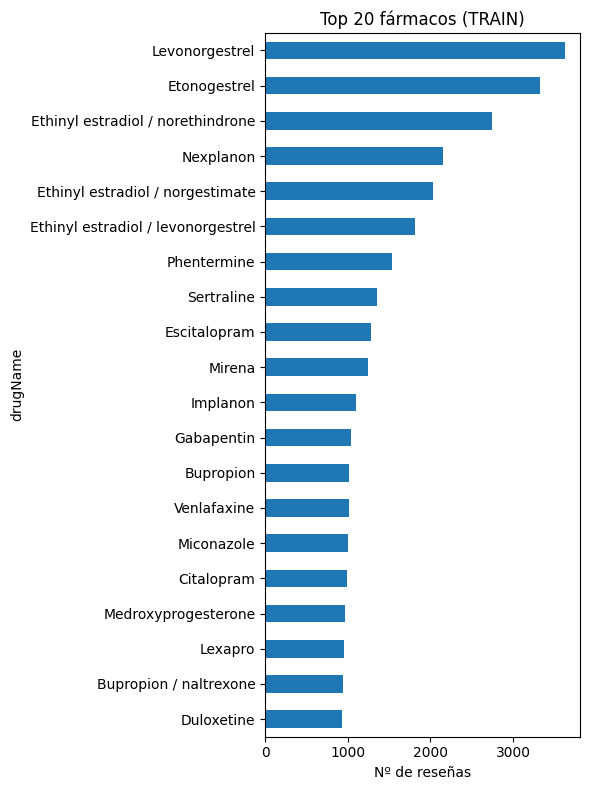

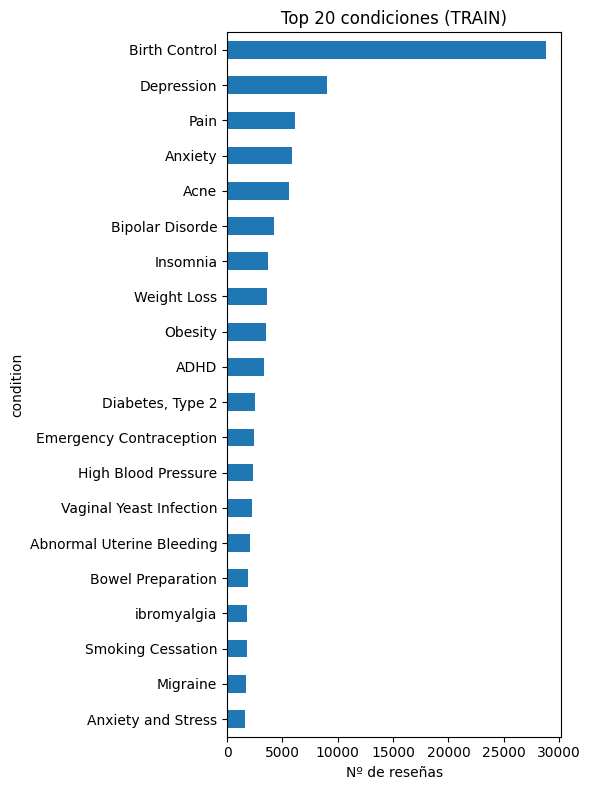

In [54]:
import matplotlib.pyplot as plt

top_n = 20

top_drugs = df_train["drugName"].value_counts().head(top_n)[::-1]
fig, ax = plt.subplots(figsize=(6,8))
top_drugs.plot(kind="barh", ax=ax)
ax.set_title(f"Top {top_n} fármacos (TRAIN)")
ax.set_xlabel("Nº de reseñas")
plt.tight_layout()
plt.show()

top_conditions = df_train["condition"].value_counts().head(top_n)[::-1]
fig, ax = plt.subplots(figsize=(6,8))
top_conditions.plot(kind="barh", ax=ax)
ax.set_title(f"Top {top_n} condiciones (TRAIN)")
ax.set_xlabel("Nº de reseñas")
plt.tight_layout()
plt.show()

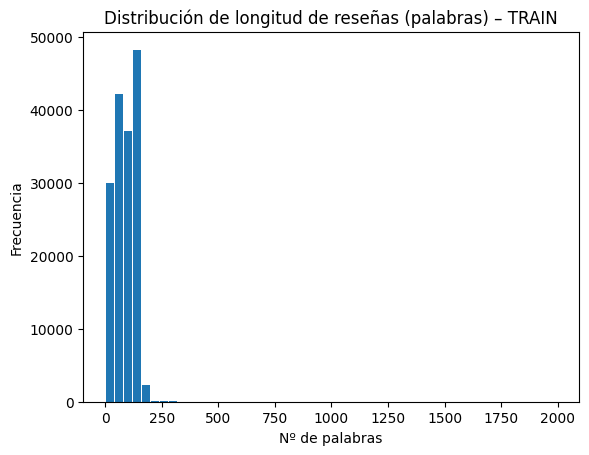

Resumen longitud (TRAIN)
count    160046.000000
mean         88.741537
std          47.212821
min           1.000000
25%          50.000000
50%          88.000000
75%         132.000000
max        1996.000000


In [55]:
fig, ax = plt.subplots()
df_train["review_len"].plot(kind="hist", bins=50, rwidth=0.9)
ax.set_title("Distribución de longitud de reseñas (palabras) – TRAIN")
ax.set_xlabel("Nº de palabras")
ax.set_ylabel("Frecuencia")
plt.show()

print("Resumen longitud (TRAIN)")
print(df_train["review_len"].describe().to_string())


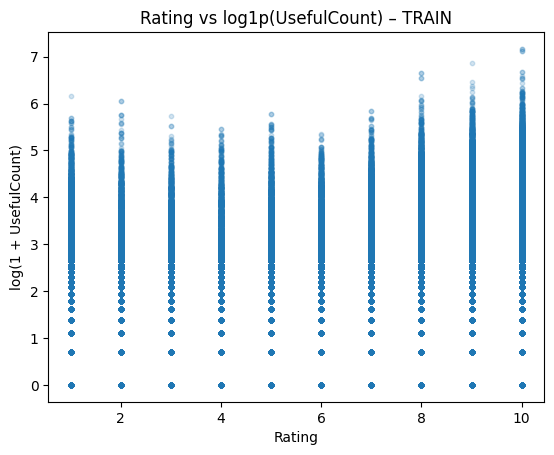

Correlación Pearson rating–usefulCount: 0.235
Correlación Spearman rating–usefulCount: 0.283


In [57]:
import numpy as np
import matplotlib.pyplot as plt

df_tmp = df_train.dropna(subset=["rating","usefulCount"]).copy()
df_tmp["useful_log1p"] = np.log1p(df_tmp["usefulCount"])

fig, ax = plt.subplots()
ax.scatter(df_tmp["rating"], df_tmp["useful_log1p"], alpha=0.2, s=10)
ax.set_title("Rating vs log1p(UsefulCount) – TRAIN")
ax.set_xlabel("Rating")
ax.set_ylabel("log(1 + UsefulCount)")
plt.show()

# Correlaciones
pearson = df_tmp[["rating","usefulCount"]].corr(method="pearson").iloc[0,1]
spearman = df_tmp[["rating","usefulCount"]].corr(method="spearman").iloc[0,1]
print(f"Correlación Pearson rating–usefulCount: {pearson:.3f}")
print(f"Correlación Spearman rating–usefulCount: {spearman:.3f}")

<Axes: xlabel='rating'>

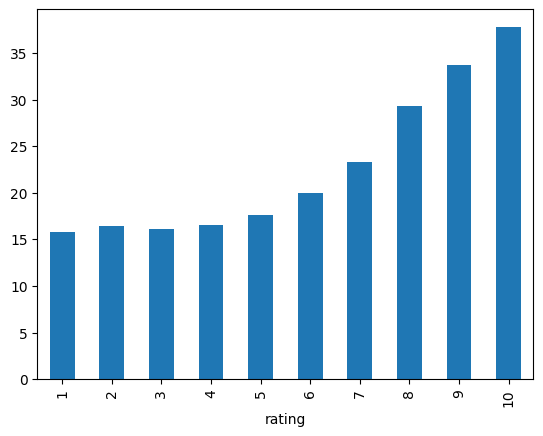

In [62]:
df_tmp.groupby("rating")["usefulCount"].mean().plot(kind="bar")

/tmp/ipython-input-641974285.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df_train.groupby("len_bin")["rating"].describe()


           count      mean       std  min   25%  50%   75%   max
len_bin                                                         
≤50      40019.0  6.881606  3.450575  1.0  4.00  8.0  10.0  10.0
51–100   51676.0  6.950151  3.285445  1.0  4.00  8.0  10.0  10.0
101–200  68054.0  7.088738  3.150516  1.0  5.00  8.0  10.0  10.0
201–400    239.0  7.234310  3.424380  1.0  5.00  9.0  10.0  10.0
401–800     48.0  6.020833  3.806431  1.0  1.00  8.0   9.0  10.0
>800        10.0  7.400000  3.339993  2.0  4.25  9.0  10.0  10.0


/tmp/ipython-input-641974285.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False)


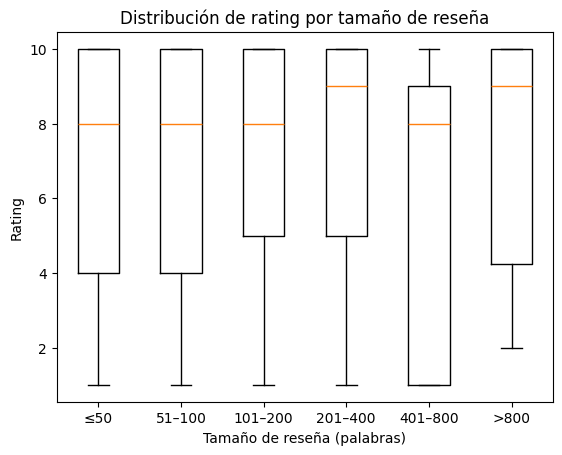

In [58]:
bins = [0, 50, 100, 200, 400, 800, 20000]
labels = ["≤50","51–100","101–200","201–400","401–800",">800"]
df_train["len_bin"] = pd.cut(df_train["review_len"], bins=bins, labels=labels, include_lowest=True)

grp = df_train.groupby("len_bin")["rating"].describe()
print(grp.to_string())

# Boxplot manual con matplotlib
data_to_plot = [df_train.loc[df_train["len_bin"]==lab, "rating"].values for lab in labels]
fig, ax = plt.subplots()
ax.boxplot(data_to_plot, labels=labels, showfliers=False)
ax.set_title("Distribución de rating por tamaño de reseña")
ax.set_xlabel("Tamaño de reseña (palabras)")
ax.set_ylabel("Rating")
plt.show()


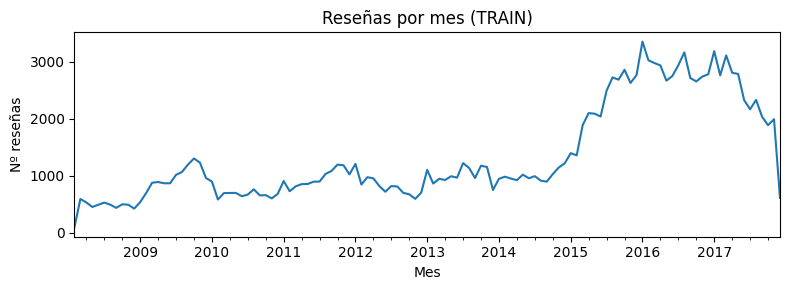

In [59]:
df_time = df_train.dropna(subset=["date"]).copy()
df_time["ym"] = df_time["date"].dt.to_period("M").dt.to_timestamp()

ts = df_time.groupby("ym").size()
fig, ax = plt.subplots(figsize=(8,3))
ts.plot(ax=ax)
ax.set_title("Reseñas por mes (TRAIN)")
ax.set_xlabel("Mes")
ax.set_ylabel("Nº reseñas")
plt.tight_layout()
plt.show()


In [60]:
print("Nulos (TRAIN):")
print(df_train[["drugName","condition","review_clean","rating","date","usefulCount"]].isnull().sum())

q99 = df_train["usefulCount"].quantile(0.99)
extremos = df_train[df_train["usefulCount"] > q99][["drugName","condition","rating","usefulCount"]].head(10)
print(f"\nUmbral p99 usefulCount: {q99:.0f}")
print("Ejemplos de outliers en usefulCount:")
print(extremos.to_string(index=False))


Nulos (TRAIN):
drugName        0
condition       0
review_clean    0
rating          0
date            0
usefulCount     0
dtype: int64

Umbral p99 usefulCount: 167
Ejemplos de outliers en usefulCount:
     drugName                             condition  rating  usefulCount
   Guanfacine                                  ADHD       8          192
 Escitalopram                            Depression       8          376
 Liothyronine Hypothyroidism, After Thyroid Removal       9          169
     Seroquel           Generalized Anxiety Disorde       8          215
   Clonazepam                               Anxiety      10          261
       Zoloft                            Depression      10          179
   Fluoxetine                    Anxiety and Stress      10          173
Amitriptyline                                  Pain       8          176
Wellbutrin SR                                  ADHD      10          230
      Lexapro                               Anxiety      10         

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


Accuracy: 0.568
F1-score: 0.585


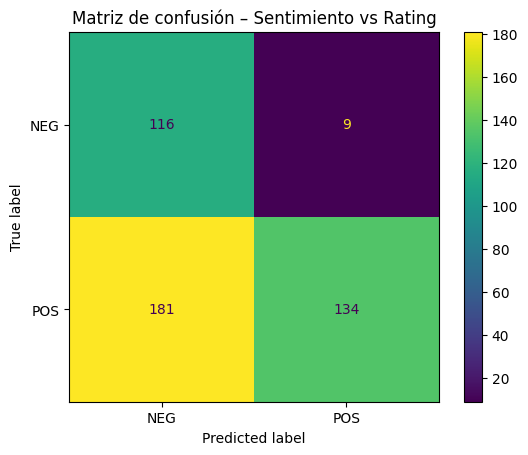

In [63]:
# ================================
# Análisis de Sentimiento vs Rating
# ================================

from transformers import pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# 1. Seleccionamos una muestra razonable (para no saturar la GPU/CPU)
sample = df_train.sample(500, random_state=42).copy()

# 2. Definimos etiquetas reales basadas en el rating
def rating_to_sentiment(r):
    if r >= 7: return "POSITIVE"
    elif r <= 4: return "NEGATIVE"
    else: return "NEUTRAL"

sample["true_sentiment"] = sample["rating"].apply(rating_to_sentiment)

# 3. Cargamos pipeline de sentimiento (modelo en inglés)
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0  # Si hay GPU, usa 0; si no, usa -1
)

# 4. Aplicamos el modelo a las reseñas limpias
sample["predicted_sentiment"] = sample["review_clean"].apply(lambda x: sentiment_model(x[:512])[0]["label"])

# 5. Excluimos casos NEUTRAL para comparar binario (positivo vs negativo)
df_eval = sample[sample["true_sentiment"].isin(["POSITIVE", "NEGATIVE"])].copy()

# Convertimos etiquetas a binario
y_true = np.where(df_eval["true_sentiment"] == "POSITIVE", 1, 0)
y_pred = np.where(df_eval["predicted_sentiment"].str.upper() == "POSITIVE", 1, 0)

# 6. Métricas
acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print(f"Accuracy: {acc:.3f}")
print(f"F1-score: {f1:.3f}")
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NEG","POS"]).plot()
plt.title("Matriz de confusión – Sentimiento vs Rating")
plt.show()


**Sesgo hacia lo negativo:**

El modelo tiende a clasificar muchos textos como negativos (181 falsos negativos), lo cual indica que el lenguaje de las reseñas médicas puede sonar “frío” o “crítico” incluso cuando el rating es alto.

Ejemplo típico:

“Worked well, but had severe side effects at first” → rating 8, pero el modelo lo ve como negativo.

- Excelente precisión en reseñas negativas (116 de 125 correctas)
Cuando detecta algo negativo, suele acertar.

- Problema de recall en positivas: Falla en identificar correctamente los textos positivos.
Puede deberse a que:

- El modelo fue entrenado en reseñas genéricas (películas, productos), no en textos médicos.

- En salud, los pacientes usan lenguaje neutral o mixto (“funciona, pero me causa mareos”).

- Hay clases desbalanceadas (más reseñas positivas en el dataset original).

Device set to use cpu


Correlación Pearson:  0.426
Correlación Spearman: 0.514


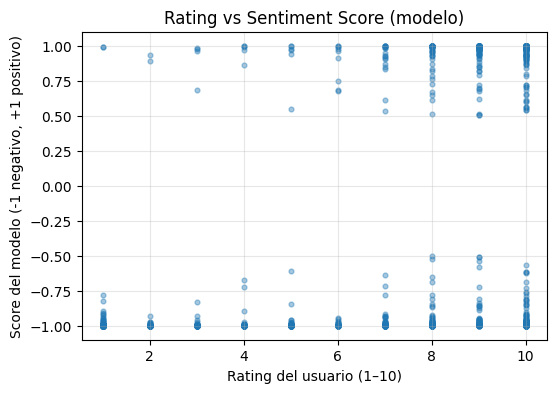

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from transformers import pipeline

# Usamos una muestra para rapidez
sample = df_train.sample(1000, random_state=42).copy()

# Pipeline de sentimiento (modelo en inglés)
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0  # o -1 si CPU
)

# Aplicamos modelo
results = sentiment_model(sample["review_clean"].tolist(), truncation=True)

# Convertimos resultados a DataFrame
sample["pred_label"] = [r["label"] for r in results]
sample["score_raw"] = [r["score"] for r in results]

# Asignamos signo negativo si el sentimiento es NEGATIVE
sample["sentiment_score"] = np.where(
    sample["pred_label"].str.upper() == "POSITIVE",
    sample["score_raw"],
    -sample["score_raw"]
)

# Correlaciones
pearson_corr, _ = pearsonr(sample["rating"], sample["sentiment_score"])
spearman_corr, _ = spearmanr(sample["rating"], sample["sentiment_score"])

print(f"Correlación Pearson:  {pearson_corr:.3f}")
print(f"Correlación Spearman: {spearman_corr:.3f}")

# Visualización
plt.figure(figsize=(6,4))
plt.scatter(sample["rating"], sample["sentiment_score"], alpha=0.4, s=12)
plt.title("Rating vs Sentiment Score (modelo)")
plt.xlabel("Rating del usuario (1–10)")
plt.ylabel("Score del modelo (-1 negativo, +1 positivo)")
plt.grid(True, alpha=0.3)
plt.show()


##**Trabajemos el bot**

In [65]:
# ================================
# BOT sobre Drug Reviews (batch)
# Requiere: df_train / df_test con 'review_clean'
# ================================
import re, json, numpy as np, pandas as pd
from transformers import pipeline

# 0) Parámetros
N_ROWS = 500            # nº de reviews a procesar (ajusta según recursos)
BATCH_SIZE = 32         # tamaño de lote para pipelines HF
USESET = "train"        # "train" o "test"

df = df_train if USESET == "train" else df_test
df = df.copy().head(N_ROWS)  # demo rápida;

In [68]:
df.head()

,drugName,condition,review,rating,date,usefulCount,review_clean,review_len,len_bin
0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,"it has no side effect, i take it in combinatio...",17,≤50
1,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,my son is halfway through his fourth week of i...,142,101–200
2,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,"i used to take another oral contraceptive, whi...",138,101–200
3,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,this is my first time using any form of birth ...,93,51–100
4,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,suboxone has completely turned my life around....,133,101–200


In [69]:
# 1) Pipelines (CPU: device=-1; GPU: device=0)
sentiment_pipe = pipeline("sentiment-analysis",
                          model="distilbert-base-uncased-finetuned-sst-2-english",
                          device=0 if False else -1)
summarizer_pipe = pipeline("summarization",
                           model="sshleifer/distilbart-cnn-12-6",
                           device=0 if False else -1)
ner_pipe = pipeline("ner",
                    model="dslim/bert-base-NER",
                    aggregation_strategy="simple",
                    device=0 if False else -1)

def chunker(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

def safe_text(x):
    s = re.sub(r"\s+", " ", str(x)).strip()
    return s if s else " "

Device set to use cpu


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


In [70]:
# 2) Sentimiento por lotes (obtenemos etiqueta y score con signo)
texts = df["review_clean"].astype(str).apply(lambda x: x[:512]).tolist()  # truncado seguro
labels, signed_scores = [], []
for batch in chunker(texts, BATCH_SIZE):
    outs = sentiment_pipe(batch, truncation=True)
    for o in outs:
        lab = o["label"].upper()
        sc  = o["score"]
        labels.append(lab)
        signed_scores.append(sc if lab=="POSITIVE" else -sc)

df["bot_sentiment_label"] = labels
df["bot_sentiment_score"] = signed_scores

In [71]:
# 3) Resumen por lotes (síntesis breve de la experiencia)
summaries = []
for batch in chunker(texts, BATCH_SIZE):
    outs = summarizer_pipe(batch, max_length=70, min_length=20, do_sample=False)
    summaries.extend([o["summary_text"] for o in outs])
df["bot_summary"] = summaries

Your max_length is set to 70, but your input_length is only 22. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=11)
Your max_length is set to 70, but your input_length is only 43. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=21)
Your max_length is set to 70, but your input_length is only 52. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=26)
Your max_length is set to 70, but your input_length is only 50. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=25)
Your max

In [72]:
df

,drugName,condition,review,rating,date,usefulCount,review_clean,review_len,len_bin,bot_sentiment_label,bot_sentiment_score,bot_summary
0,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,"it has no side effect, i take it in combinatio...",17,≤50,NEGATIVE,-0.936557,"It has no side effect, i take it in combinati..."
1,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,my son is halfway through his fourth week of i...,142,101–200,NEGATIVE,-0.799136,My son is halfway through his fourth week of ...
2,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,"i used to take another oral contraceptive, whi...",138,101–200,NEGATIVE,-0.998671,"i used to take another oral contraceptive, wh..."
3,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,this is my first time using any form of birth ...,93,51–100,NEGATIVE,-0.948000,This is my first time using any form of birth...
4,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,suboxone has completely turned my life around....,133,101–200,POSITIVE,0.933926,suboxone has completely turned my life around...
...,...,...,...,...,...,...,...,...,...,...,...,...
498,Oxycodone,Pain,"""Had disc replaced L5- S1 with laminectomy plu...",9,2011-12-13,8,had disc replaced l5 s1 with laminectomy plus...,48,≤50,POSITIVE,0.964404,Had disc replaced l5 s1 with laminectomy plu...
499,Plan B,Emergency Contraception,"""Plan B definitely helps with not getting preg...",3,2014-09-17,26,plan b definitely helps with not getting pregn...,26,≤50,NEGATIVE,-0.995344,i react super bad to hormones so this has bee...
500,Focalin XR,ADHD,"""I was diagnosed with ADD when I was seven, I ...",8,2014-01-23,51,"i was diagnosed with add when i was seven, i t...",144,101–200,NEGATIVE,-0.998889,"i was diagnosed with add when i was seven, i ..."
501,Ethinyl estradiol / levonorgestrel,Birth Control,"""I&#039;ve been using Alesse for about 2 years...",8,2015-06-04,6,i 039 ve been using alesse for about 2 years ...,145,101–200,NEGATIVE,-0.998708,i 039 ve been using alesse for about 2 years...


In [76]:
# 4) Entidades (opcional). Extraemos tokens de tipo ORG/MISC/PER como proxy simple;
# en reviews médicas suele capturar marcas o nombres propios.
ents = []
for batch in chunker(texts, BATCH_SIZE):
    try:
        outs = ner_pipe(batch)
    except Exception:
        outs = [[] for _ in batch]
    # Convertimos a lista simple de palabras únicas
    for E in outs:
        toks = [e["word"] for e in E if e.get("entity_group") in {"ORG","MISC","PER","LOC"}]
        toks = [t for t in toks if len(t) > 1]
        ents.append(sorted(list(set(toks)))[:8])
df["bot_entities"] = ents

In [73]:
# 5) Plantilla de respuesta empática + educativa
def make_reply(row):
    drug = row.get("drugName", "")
    cond = row.get("condition", "")
    rating = row.get("rating", np.nan)
    useful = row.get("usefulCount", np.nan)
    label = row.get("bot_sentiment_label", "NEUTRAL")
    score = row.get("bot_sentiment_score", 0.0)
    summary = row.get("bot_summary", "")
    found = row.get("bot_entities", [])

    # tono empático según sentimiento
    if label == "NEGATIVE":
        opening = "Lamento que tu experiencia no haya sido plenamente satisfactoria."
    elif label == "POSITIVE":
        opening = "¡Gracias por compartir una experiencia positiva!"
    else:
        opening = "Gracias por contar tu experiencia."

    # pistas detectadas
    ctx = []
    if isinstance(drug, str) and drug:
        ctx.append(f"medicamento: {drug}")
    if isinstance(cond, str) and cond:
        ctx.append(f"condición: {cond}")
    if found:
        ctx.append("palabras clave: " + ", ".join(found[:5]))
    ctx_txt = (" (" + "; ".join(ctx) + ")") if ctx else ""

    # recomendaciones educativas (neutras, no clínicas)
    tips = [
        "Esta información es educativa y no sustituye la orientación de tu profesional de salud.",
        "Si notas efectos adversos o dudas sobre la dosis, consulta con tu profesional sanitario.",
        "Revisa fuentes fiables (p. ej., MedlinePlus/NIH) para saber más sobre uso y efectos habituales.",
    ]
    if pd.notna(useful) and useful >= 50:
        tips.append("Gracias: tu reseña ha sido muy útil para otras personas.")

    reply = (
        f"{opening}{ctx_txt}\n\n"
        f"Resumen de lo que cuentas: {summary}\n"
        f"Mi lectura del tono: {label.title()} (score {score:.2f}).\n\n"
        f"Sugerencias educativas:\n"
        f"• {tips[0]}\n"
        f"• {tips[1]}\n"
        f"• {tips[2]}"
    )
    if len(tips) == 4:
        reply += f"\n• {tips[3]}"
    return reply

df["bot_reply"] = df.apply(make_reply, axis=1)

In [78]:
# 6) Salida: mostramos ejemplos y guardamos CSV
cols_out = ["drugName","condition","rating","usefulCount","review","bot_sentiment_label",
            "bot_sentiment_score","bot_summary","bot_entities","bot_reply"]
display(df[cols_out].head(5))

out_path = path + "Train_with_bot_replies.csv"
df[cols_out].to_csv(out_path, index=False)
print(f"CSV generado: {out_path}")

,drugName,condition,rating,usefulCount,review,bot_sentiment_label,bot_sentiment_score,bot_summary,bot_entities,bot_reply
0,Valsartan,Left Ventricular Dysfunction,9,27,"""It has no side effect, I take it in combinati...",NEGATIVE,-0.936557,"It has no side effect, i take it in combinati...",[],Lamento que tu experiencia no haya sido plenam...
1,Guanfacine,ADHD,8,192,"""My son is halfway through his fourth week of ...",NEGATIVE,-0.799136,My son is halfway through his fourth week of ...,[],Lamento que tu experiencia no haya sido plenam...
2,Lybrel,Birth Control,5,17,"""I used to take another oral contraceptive, wh...",NEGATIVE,-0.998671,"i used to take another oral contraceptive, wh...",[],Lamento que tu experiencia no haya sido plenam...
3,Ortho Evra,Birth Control,8,10,"""This is my first time using any form of birth...",NEGATIVE,-0.948000,This is my first time using any form of birth...,[],Lamento que tu experiencia no haya sido plenam...
4,Buprenorphine / naloxone,Opiate Dependence,9,37,"""Suboxone has completely turned my life around...",POSITIVE,0.933926,suboxone has completely turned my life around...,[],¡Gracias por compartir una experiencia positiv...


CSV generado: /content/drive/MyDrive/Colab Notebooks/Python-Ejercicios/07 - PLN/ACTIVIDADES CURSO/Train_with_bot_replies.csv


In [79]:
respuestas  = path + "Train_with_bot_replies.csv"

df_respuesta = pd.read_csv(respuestas)

In [82]:
print(df_respuesta.bot_reply)


0      Lamento que tu experiencia no haya sido plenam...
1      Lamento que tu experiencia no haya sido plenam...
2      Lamento que tu experiencia no haya sido plenam...
3      Lamento que tu experiencia no haya sido plenam...
4      ¡Gracias por compartir una experiencia positiv...
                             ...                        
495    ¡Gracias por compartir una experiencia positiv...
496    Lamento que tu experiencia no haya sido plenam...
497    Lamento que tu experiencia no haya sido plenam...
498    Lamento que tu experiencia no haya sido plenam...
499    Lamento que tu experiencia no haya sido plenam...
Name: bot_reply, Length: 500, dtype: object
